# week 4 worksheet fcn devnagari digits

In [15]:
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras

# same runs each time
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('tf ver:', tf.__version__)

tf ver: 2.21.0


In [16]:
# data paths (use your actual devnagari dataset only)
DATASET_ROOT = Path('week4') / 'DevanagariHandwrittenDigitDataset'
TRAIN_DIR = DATASET_ROOT / 'Train'
TEST_DIR = DATASET_ROOT / 'Test'

IMG_HEIGHT, IMG_WIDTH = 28, 28
NUM_CLASSES = 10

if not TRAIN_DIR.exists() or not TEST_DIR.exists():
    raise FileNotFoundError(
        'dataset not found. expected folder: week4/DevanagariHandwrittenDigitDataset with Train and Test'
    )

print('train dir:', TRAIN_DIR.resolve())
print('test dir :', TEST_DIR.resolve())

train dir: C:\Users\lenovo\Desktop\Ai herald last sem\week4\DevanagariHandwrittenDigitDataset\Train
test dir : C:\Users\lenovo\Desktop\Ai herald last sem\week4\DevanagariHandwrittenDigitDataset\Test


In [17]:
def load_images_from_folder(folder: Path, img_size=(28, 28)):
    """load grayscale imgs + int labels from class folders"""
    images = []
    labels = []

    class_names = sorted([d.name for d in folder.iterdir() if d.is_dir()])
    class_to_idx = {name: idx for idx, name in enumerate(class_names)}

    for class_name in class_names:
        class_path = folder / class_name
        label = class_to_idx[class_name]

        for file_path in class_path.iterdir():
            if not file_path.is_file():
                continue
            try:
                img = Image.open(file_path).convert('L')
                img = img.resize(img_size)
                arr = np.array(img, dtype=np.float32) / 255.0
                images.append(arr)
                labels.append(label)
            except Exception:
                # skip weird files
                continue

    return np.array(images, dtype=np.float32), np.array(labels, dtype=np.int32), class_names


x_train, y_train_int, train_class_names = load_images_from_folder(TRAIN_DIR, (IMG_HEIGHT, IMG_WIDTH))
x_test, y_test_int, test_class_names = load_images_from_folder(TEST_DIR, (IMG_HEIGHT, IMG_WIDTH))

assert train_class_names == test_class_names, 'train/test class folders do not match'
print('classes:', train_class_names)

# fcn wants flat vectors
x_train = x_train.reshape(-1, IMG_HEIGHT * IMG_WIDTH)
x_test = x_test.reshape(-1, IMG_HEIGHT * IMG_WIDTH)

# one-hot labels
y_train = keras.utils.to_categorical(y_train_int, NUM_CLASSES)
y_test = keras.utils.to_categorical(y_test_int, NUM_CLASSES)

print('x_train:', x_train.shape)
print('y_train:', y_train.shape)
print('x_test :', x_test.shape)
print('y_test :', y_test.shape)

classes: ['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']
x_train: (17000, 784)
y_train: (17000, 10)
x_test : (3000, 784)
y_test : (3000, 10)


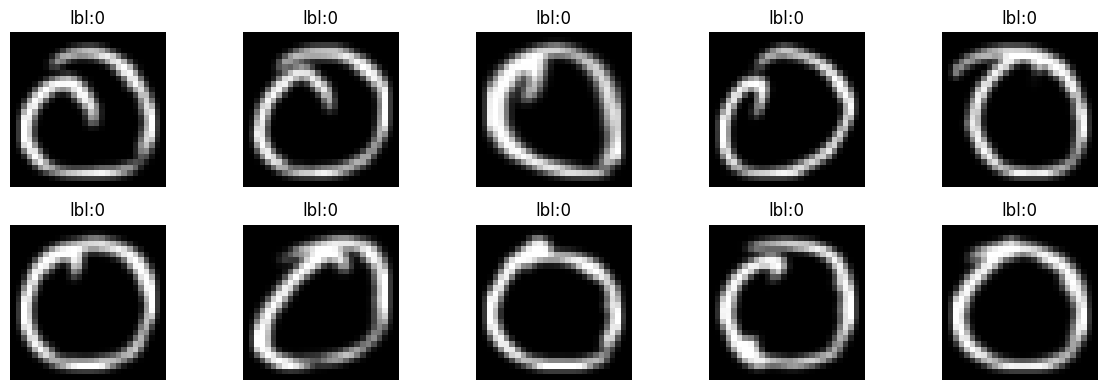

In [18]:
# quick sample viz
plt.figure(figsize=(12, 4))
for i in range(min(10, len(x_train))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    plt.title(f'lbl:{np.argmax(y_train[i])}')
    plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# build model
model = keras.Sequential([
    keras.layers.Input(shape=(IMG_HEIGHT * IMG_WIDTH,)),
    keras.layers.Dense(64, activation='sigmoid'),
    keras.layers.Dense(128, activation='sigmoid'),
    keras.layers.Dense(256, activation='sigmoid'),
    keras.layers.Dense(NUM_CLASSES, activation='softmax')
])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [20]:
# compile + train
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

BATCH_SIZE = 128
EPOCHS = 20

callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath='best_devnagari_fcn.keras', monitor='val_accuracy', save_best_only=True, mode='max'
    ),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True)
]

history = model.fit(
    x_train,
    y_train,
    batch_size=BATCH_SIZE,
    epochs=EPOCHS,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1,
)

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.4611 - loss: 1.6613 - val_accuracy: 0.0000e+00 - val_loss: 6.8999
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8264 - loss: 0.5345 - val_accuracy: 0.0000e+00 - val_loss: 8.1151
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9075 - loss: 0.2928 - val_accuracy: 0.0000e+00 - val_loss: 8.5468
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9457 - loss: 0.1927 - val_accuracy: 0.0000e+00 - val_loss: 8.9422
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9595 - loss: 0.1425 - val_accuracy: 0.0000e+00 - val_loss: 9.2502


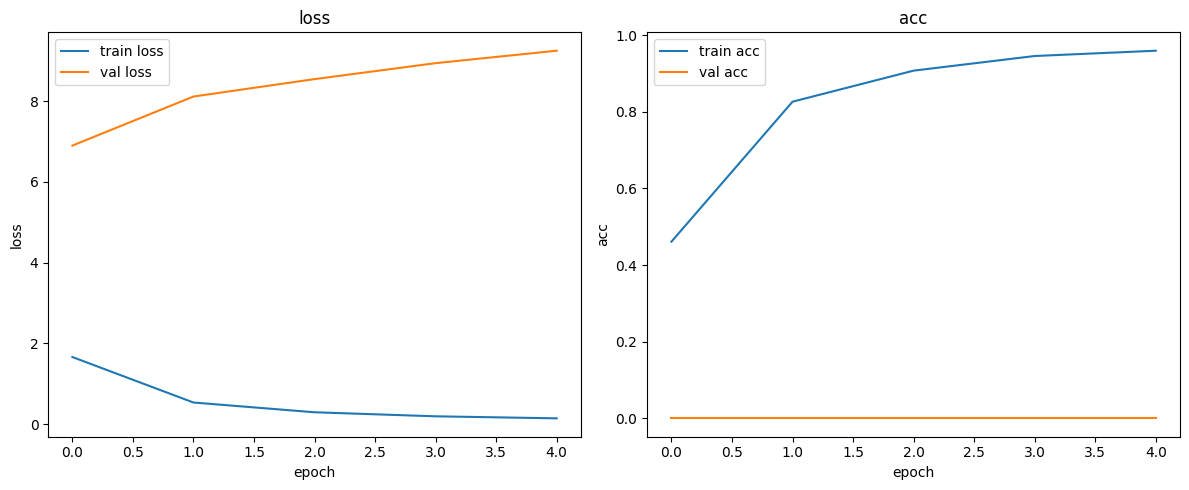

In [21]:
# training curves
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_loss, label='train loss')
plt.plot(val_loss, label='val loss')
plt.title('loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(train_acc, label='train acc')
plt.plot(val_acc, label='val acc')
plt.title('acc')
plt.xlabel('epoch')
plt.ylabel('acc')
plt.legend()
plt.tight_layout()
plt.show()

In [22]:
# eval
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f'test loss: {test_loss:.4f}')
print(f'test acc : {test_acc:.4f}')

94/94 - 0s - 2ms/step - accuracy: 0.6043 - loss: 2.0677
test loss: 2.0677
test acc : 0.6043


In [23]:
# save + load
MODEL_H5_PATH = 'devnagari_fcn_model.h5'
model.save(MODEL_H5_PATH)
print('saved:', MODEL_H5_PATH)

loaded_model = keras.models.load_model(MODEL_H5_PATH)
loaded_loss, loaded_acc = loaded_model.evaluate(x_test, y_test, verbose=0)
print(f'loaded test loss: {loaded_loss:.4f}')
print(f'loaded test acc : {loaded_acc:.4f}')

saved: devnagari_fcn_model.h5
loaded test loss: 2.0677
loaded test acc : 0.6043


first sample:
pred: 0
true: 0


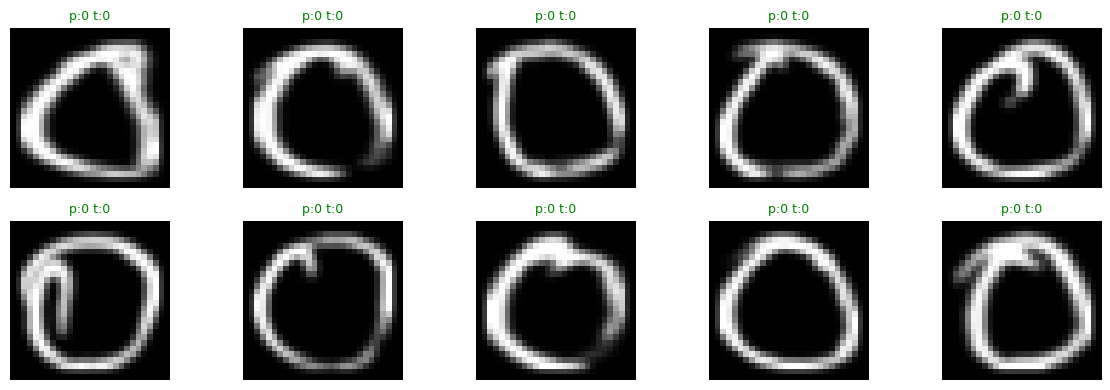

In [24]:
# predict
predictions = loaded_model.predict(x_test, verbose=0)
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

print('first sample:')
print('pred:', predicted_labels[0])
print('true:', true_labels[0])

plt.figure(figsize=(12, 4))
for i in range(min(10, len(x_test))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(IMG_HEIGHT, IMG_WIDTH), cmap='gray')
    c = 'green' if predicted_labels[i] == true_labels[i] else 'red'
    plt.title(f'p:{predicted_labels[i]} t:{true_labels[i]}', color=c, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()